Methodology: EDA, Preprocessing, Feature Engineering, Class Imbalance Handling

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LassoCV
from sklearn.feature_selection import RFE
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Seed
np.random.seed(42)

print('Libraries loaded successfully.')

Libraries loaded successfully.


1. Data Loading

In [ ]:
# Paths 
base_path = 'TCGA-BRCA Dataset'
clinical_patient_path = os.path.join(base_path, 'data_clinical_patient.txt')
clinical_sample_path  = os.path.join(base_path, 'data_clinical_sample.txt')
mrna_data_path        = os.path.join(base_path, 'data_mrna_seq_v2_rsem.txt')

In [ ]:
# Load clinical patient data
df_patient = pd.read_csv(clinical_patient_path, sep='\t', comment='#')
print(f'Clinical Patient Shape: {df_patient.shape}')
print(df_patient.head(3))

Clinical Patient Shape: (1084, 38)
     PATIENT_ID    SUBTYPE CANCER_TYPE_ACRONYM  \
0  TCGA-3C-AAAU  BRCA_LumA                BRCA   
1  TCGA-3C-AALI  BRCA_Her2                BRCA   
2  TCGA-3C-AALJ  BRCA_LumB                BRCA   

                       OTHER_PATIENT_ID  AGE     SEX  \
0  6E7D5EC6-A469-467C-B748-237353C23416   55  Female   
1  55262FCB-1B01-4480-B322-36570430C917   50  Female   
2  427D0648-3F77-4FFC-B52C-89855426D647   62  Female   

  AJCC_PATHOLOGIC_TUMOR_STAGE AJCC_STAGING_EDITION  DAYS_LAST_FOLLOWUP  \
0                     STAGE X                  6TH              4047.0   
1                   STAGE IIB                  6TH              4005.0   
2                   STAGE IIB                  7TH              1474.0   

   DAYS_TO_BIRTH  ...  IN_PANCANPATHWAYS_FREEZE OS_STATUS   OS_MONTHS  \
0       -20211.0  ...                       Yes  0:LIVING  133.050597   
1       -18538.0  ...                       Yes  0:LIVING  131.669790   
2       -22848.0  ...  

In [ ]:
# Load clinical sample data
df_sample = pd.read_csv(clinical_sample_path, sep='\t', comment='#')
print(f'Clinical Sample Shape: {df_sample.shape}')
print(df_sample.head(3))

Clinical Sample Shape: (1084, 19)
     PATIENT_ID        SAMPLE_ID ONCOTREE_CODE    CANCER_TYPE  \
0  TCGA-3C-AAAU  TCGA-3C-AAAU-01           ILC  Breast Cancer   
1  TCGA-3C-AALI  TCGA-3C-AALI-01           IDC  Breast Cancer   
2  TCGA-3C-AALJ  TCGA-3C-AALJ-01           IDC  Breast Cancer   

                CANCER_TYPE_DETAILED                      TUMOR_TYPE  GRADE  \
0  Breast Invasive Lobular Carcinoma  Infiltrating Lobular Carcinoma    NaN   
1   Breast Invasive Ductal Carcinoma   Infiltrating Ductal Carcinoma    NaN   
2   Breast Invasive Ductal Carcinoma   Infiltrating Ductal Carcinoma    NaN   

  TISSUE_PROSPECTIVE_COLLECTION_INDICATOR  \
0                                      No   
1                                      No   
2                                      No   

  TISSUE_RETROSPECTIVE_COLLECTION_INDICATOR TISSUE_SOURCE_SITE_CODE  \
0                                       Yes                      3C   
1                                       Yes                      

In [ ]:
# Load mRNA expression data
# Genes as rows, samples as columns; first two cols are Hugo_Symbol & Entrez_Gene_Id
df_mrna_raw = pd.read_csv(mrna_data_path, sep='\t', index_col=0)
print(f'mRNA raw shape (genes x samples): {df_mrna_raw.shape}')
print(df_mrna_raw.iloc[:5, :5])

mRNA raw shape (genes x samples): (20531, 1083)
             Entrez_Gene_Id  TCGA-3C-AAAU-01  TCGA-3C-AALI-01  \
Hugo_Symbol                                                     
NaN               100130426           0.0000           0.0000   
NaN               100133144          16.3644           9.2659   
UBE2Q2P2          100134869          12.9316          17.3790   
HMGB1P1               10357          52.1503          69.7553   
NaN                   10431         408.0760         563.8930   

             TCGA-3C-AALJ-01  TCGA-3C-AALK-01  
Hugo_Symbol                                    
NaN                   0.9066           0.0000  
NaN                  11.6228          12.0894  
UBE2Q2P2              9.2294          11.0799  
HMGB1P1             154.2970         143.8640  
NaN                1360.8300         865.5360  


In [ ]:
# Transpose mRNA: samples as rows, genes as columns
# Drop Entrez_Gene_Id row if present
if 'Entrez_Gene_Id' in df_mrna_raw.index:
    df_mrna_raw = df_mrna_raw.drop(index='Entrez_Gene_Id')

df_mrna = df_mrna_raw.T.copy()
df_mrna.index.name = 'SAMPLE_ID'
df_mrna = df_mrna.reset_index()
print(f'mRNA transposed shape: {df_mrna.shape}')

mRNA transposed shape: (1083, 20532)


In [ ]:
# Extract PAM50 subtype labels from clinical sample or patient file
# Check available columns for subtype information
print('Sample columns:', df_sample.columns.tolist())
print('Patient columns:', df_patient.columns.tolist())

Sample columns: ['PATIENT_ID', 'SAMPLE_ID', 'ONCOTREE_CODE', 'CANCER_TYPE', 'CANCER_TYPE_DETAILED', 'TUMOR_TYPE', 'GRADE', 'TISSUE_PROSPECTIVE_COLLECTION_INDICATOR', 'TISSUE_RETROSPECTIVE_COLLECTION_INDICATOR', 'TISSUE_SOURCE_SITE_CODE', 'TUMOR_TISSUE_SITE', 'ANEUPLOIDY_SCORE', 'SAMPLE_TYPE', 'MSI_SCORE_MANTIS', 'MSI_SENSOR_SCORE', 'SOMATIC_STATUS', 'TMB_NONSYNONYMOUS', 'TISSUE_SOURCE_SITE', 'TBL_SCORE']
Patient columns: ['PATIENT_ID', 'SUBTYPE', 'CANCER_TYPE_ACRONYM', 'OTHER_PATIENT_ID', 'AGE', 'SEX', 'AJCC_PATHOLOGIC_TUMOR_STAGE', 'AJCC_STAGING_EDITION', 'DAYS_LAST_FOLLOWUP', 'DAYS_TO_BIRTH', 'DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS', 'ETHNICITY', 'FORM_COMPLETION_DATE', 'HISTORY_NEOADJUVANT_TRTYN', 'ICD_10', 'ICD_O_3_HISTOLOGY', 'ICD_O_3_SITE', 'INFORMED_CONSENT_VERIFIED', 'NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT', 'PATH_M_STAGE', 'PATH_N_STAGE', 'PATH_T_STAGE', 'PERSON_NEOPLASM_CANCER_STATUS', 'PRIMARY_LYMPH_NODE_PRESENTATION_ASSESSMENT', 'PRIOR_DX', 'RACE', 'RADIATION_THERAPY', 'WEIG

In [ ]:
# Identify subtype column (PAM50)
# Common column names: SUBTYPE, CANCER_TYPE_DETAILED, PAM50_SUBTYPE
subtype_col = None
for col in df_sample.columns:
    if 'subtype' in col.lower() or 'pam50' in col.lower():
        subtype_col = col
        break
if subtype_col is None:
    for col in df_patient.columns:
        if 'subtype' in col.lower() or 'pam50' in col.lower():
            subtype_col = col
            break

print(f'Subtype column identified: {subtype_col}')

Subtype column identified: SUBTYPE


In [ ]:
# Build label dataframe
if subtype_col in df_sample.columns:
    id_col = [c for c in df_sample.columns if 'sample' in c.lower() or c == 'SAMPLE_ID'][0]
    df_labels = df_sample[[id_col, subtype_col]].copy()
    df_labels.columns = ['SAMPLE_ID', 'SUBTYPE']
else:
    id_col = [c for c in df_patient.columns if 'patient' in c.lower() or c == 'PATIENT_ID'][0]
    df_labels = df_patient[[id_col, subtype_col]].copy()
    df_labels.columns = ['SAMPLE_ID', 'SUBTYPE']

print(df_labels['SUBTYPE'].value_counts())

SUBTYPE
BRCA_LumA      499
BRCA_LumB      197
BRCA_Basal     171
BRCA_Her2       78
BRCA_Normal     36
Name: count, dtype: int64


In [10]:
print(df_mrna['SAMPLE_ID'].head(5).tolist()) 
print(df_labels['SAMPLE_ID'].head(5).tolist())
print(df_labels.columns.tolist())
print(df_labels['SUBTYPE'].head(5).tolist())

['Entrez_Gene_Id', 'TCGA-3C-AAAU-01', 'TCGA-3C-AALI-01', 'TCGA-3C-AALJ-01', 'TCGA-3C-AALK-01']
['TCGA-3C-AAAU', 'TCGA-3C-AALI', 'TCGA-3C-AALJ', 'TCGA-3C-AALK', 'TCGA-4H-AAAK']
['SAMPLE_ID', 'SUBTYPE']
['BRCA_LumA', 'BRCA_Her2', 'BRCA_LumB', 'BRCA_LumA', 'BRCA_LumA']


In [ ]:
# Harmonise sample IDs and merge mRNA + labels 
# Drop ENTREZ_GENE_ID row that in transposed index 
df_mrna = df_mrna[df_mrna['SAMPLE_ID'] != 'ENTREZ_GENE_ID'].copy()

# Strip the tissue code from mRNA sample IDs 
df_mrna['SAMPLE_ID'] = df_mrna['SAMPLE_ID'].str.upper().str.strip()
df_mrna['SAMPLE_ID'] = df_mrna['SAMPLE_ID'].str.rsplit('-', n=1).str[0]

# Normalise clinical IDs 
df_labels['SAMPLE_ID'] = df_labels['SAMPLE_ID'].str.upper().str.strip()

# Strip 'BRCA_' prefix from subtype labels 
df_labels['SUBTYPE'] = df_labels['SUBTYPE'].str.replace('BRCA_', '', regex=False).str.strip()

# Merge 
df_merged = pd.merge(df_mrna, df_labels, on='SAMPLE_ID', how='inner')
print(f'Merged dataset shape: {df_merged.shape}')
print(f'Class distribution after merge:\n{df_merged["SUBTYPE"].value_counts()}')

Merged dataset shape: (1082, 20533)
Class distribution after merge:
SUBTYPE
LumA      499
LumB      197
Basal     171
Her2       78
Normal     36
Name: count, dtype: int64


In [ ]:
# Drop rows with missing SUBTYPE
df_merged = df_merged.dropna(subset=['SUBTYPE'])

# Standardise subtype labels
df_merged['SUBTYPE'] = df_merged['SUBTYPE'].str.strip()

# Keep only PAM50 subtypes
valid_subtypes = ['LumA', 'LumB', 'Her2', 'Basal', 'Normal',
                  'Luminal A', 'Luminal B', 'HER2-enriched', 'Basal-like', 'Normal-like']
df_merged = df_merged[df_merged['SUBTYPE'].isin(valid_subtypes)].reset_index(drop=True)

print(f'After subtype filtering: {df_merged.shape}')
print(df_merged['SUBTYPE'].value_counts())

After subtype filtering: (981, 20533)
SUBTYPE
LumA      499
LumB      197
Basal     171
Her2       78
Normal     36
Name: count, dtype: int64


In [ ]:
# Separate features and labels 
label_col = 'SUBTYPE'
y_raw = df_merged[label_col].copy()
X_raw = df_merged.drop(columns=['SAMPLE_ID', label_col])
# Convert all gene expression columns to numeric
X_raw = X_raw.apply(pd.to_numeric, errors='coerce')
print(f'Feature matrix shape: {X_raw.shape}')
print(f'Labels shape: {y_raw.shape}')

Feature matrix shape: (981, 20531)
Labels shape: (981,)


2. Exploratory Data Analysis (EDA)

2.1 Statistical Summary

In [ ]:
# Statistical summary of first 500 genes
stats_summary = X_raw.iloc[:, :500].describe().T
stats_summary['skewness'] = X_raw.iloc[:, :500].skew()
stats_summary['kurtosis'] = X_raw.iloc[:, :500].kurtosis()
print('Statistical Summary (first 500 genes):')
print(stats_summary[['mean', 'std', 'min', '25%', '50%', '75%', 'max', 'skewness', 'kurtosis']].head(10))
print(f'\nOverall mean expression: {X_raw.values.mean():.4f}')
print(f'Overall std expression:  {X_raw.values.std():.4f}')

Statistical Summary (first 500 genes):
                 mean         std       min       25%        50%        75%  \
NaN          0.013071    0.108111    0.0000    0.0000     0.0000     0.0000   
NaN          8.645638    7.834435    0.0000    3.3673     7.1072    12.0721   
UBE2Q2P2     7.626021    5.842265    0.0000    3.8366     6.0837     9.8717   
HMGB1P1    114.411689   62.277981   28.9345   79.7227   102.4560   132.2940   
NaN       1101.797379  471.460284  345.1210  807.5270  1003.3800  1267.1800   
NaN          0.000000    0.000000    0.0000    0.0000     0.0000     0.0000   
NaN        221.066234  184.347343   18.7314  108.8250   170.1360   265.8800   
RNU12-2P     0.495219    0.609765    0.0000    0.0000     0.3361     0.7502   
SSX9P        0.153999    2.232182    0.0000    0.0000     0.0000     0.0000   
NaN          0.028731    0.591343    0.0000    0.0000     0.0000     0.0000   

                max   skewness    kurtosis  
NaN          2.0203  12.997565  206.426312  
N

2.2 Class Distribution Visualization

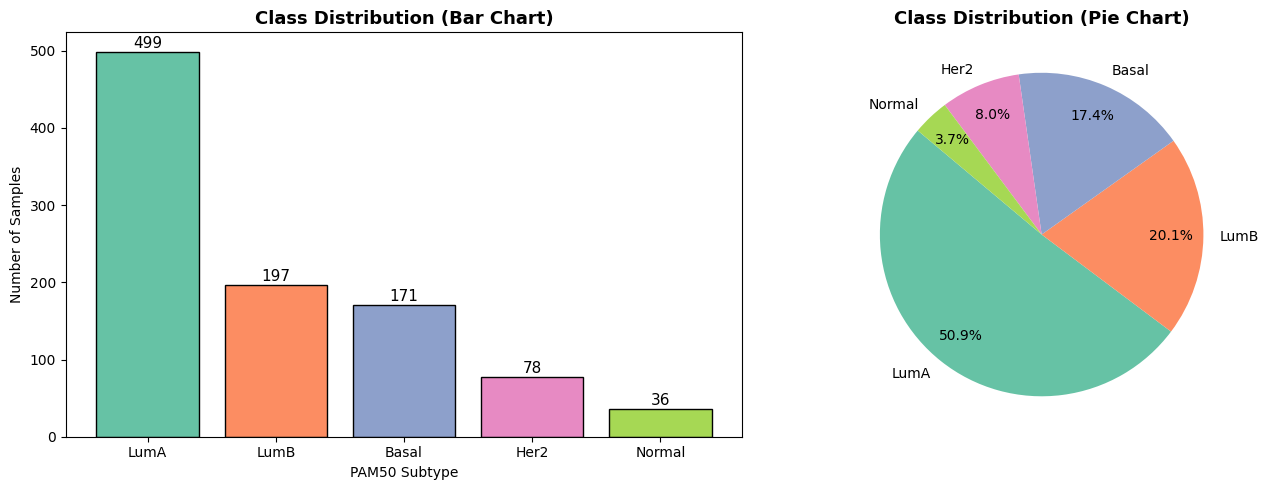

In [ ]:
class_counts = y_raw.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = sns.color_palette('Set2', len(class_counts))
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Class Distribution (Bar Chart)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PAM50 Subtype')
axes[0].set_ylabel('Number of Samples')
for i, (k, v) in enumerate(class_counts.items()):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=11)

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, pctdistance=0.8)
axes[1].set_title('Class Distribution (Pie Chart)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

2.3 Missing Value Analysis

In [16]:
missing_counts = X_raw.isnull().sum()
missing_pct = (missing_counts / len(X_raw)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_counts, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f'Total genes: {X_raw.shape[1]}')
print(f'Genes with any missing values: {len(missing_df)}')
print(f'Samples with any missing values: {X_raw.isnull().any(axis=1).sum()}')

if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    top_missing = missing_df.head(30)
    ax.bar(range(len(top_missing)), top_missing['Missing %'], color='salmon', edgecolor='black')
    ax.set_title('Missing Value Percentage (Top 30 Genes)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Gene Index')
    ax.set_ylabel('Missing Value (%)')
    plt.tight_layout()
    plt.savefig('fig2_missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No missing values detected in expression matrix.')

Total genes: 20531
Genes with any missing values: 0
Samples with any missing values: 0
No missing values detected in expression matrix.


2.4 Expression Distribution

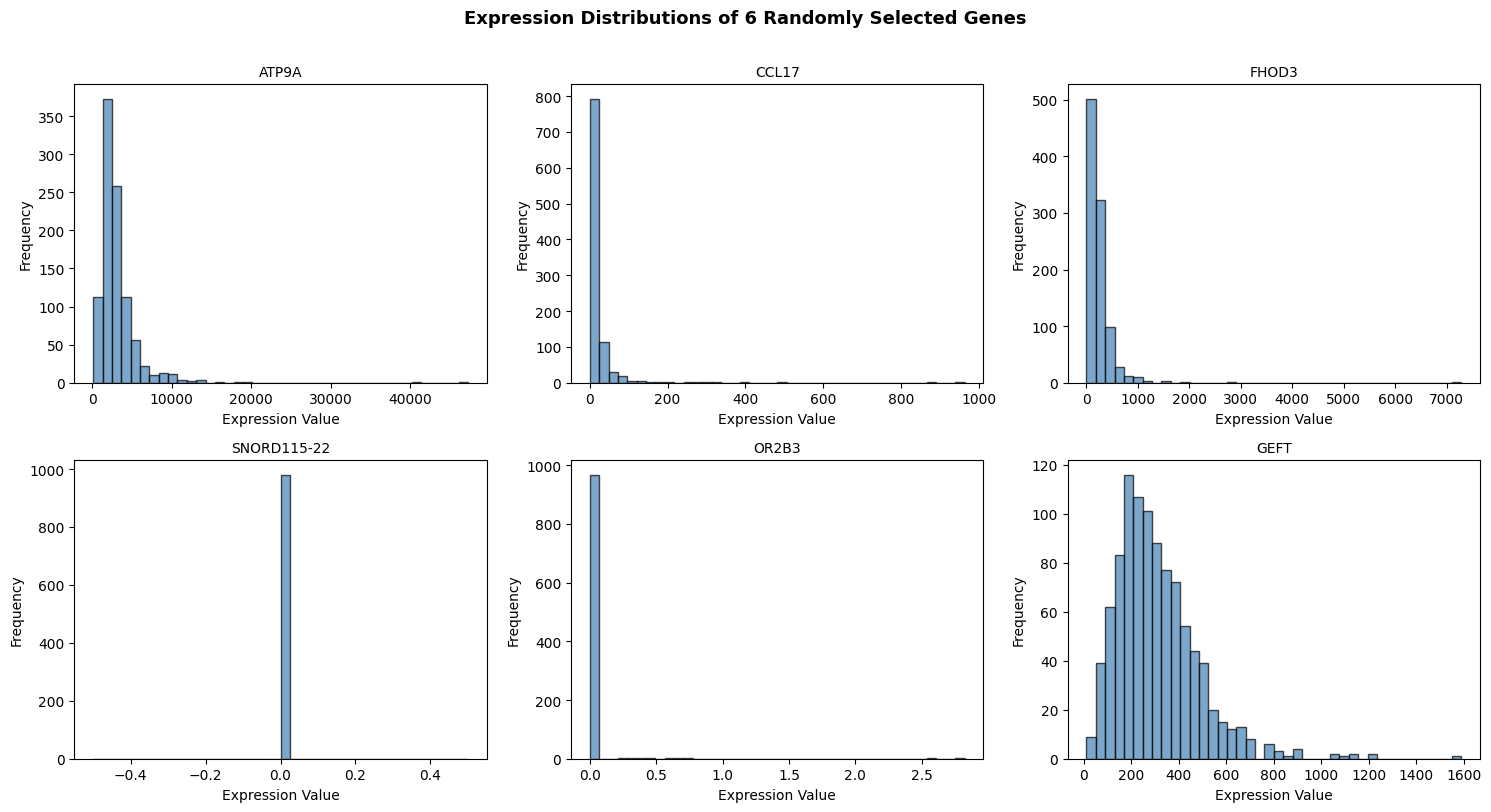

In [ ]:
# Sample 6 random genes for distribution visualization
rng_genes = X_raw.sample(n=6, axis=1, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, gene in enumerate(rng_genes.columns):
    axes[i].hist(rng_genes[gene].dropna(), bins=40, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{gene}', fontsize=10)
    axes[i].set_xlabel('Expression Value')
    axes[i].set_ylabel('Frequency')

fig.suptitle('Expression Distributions of 6 Randomly Selected Genes',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

2.5 Feature Correlation Heatmap (Top Variance Genes)

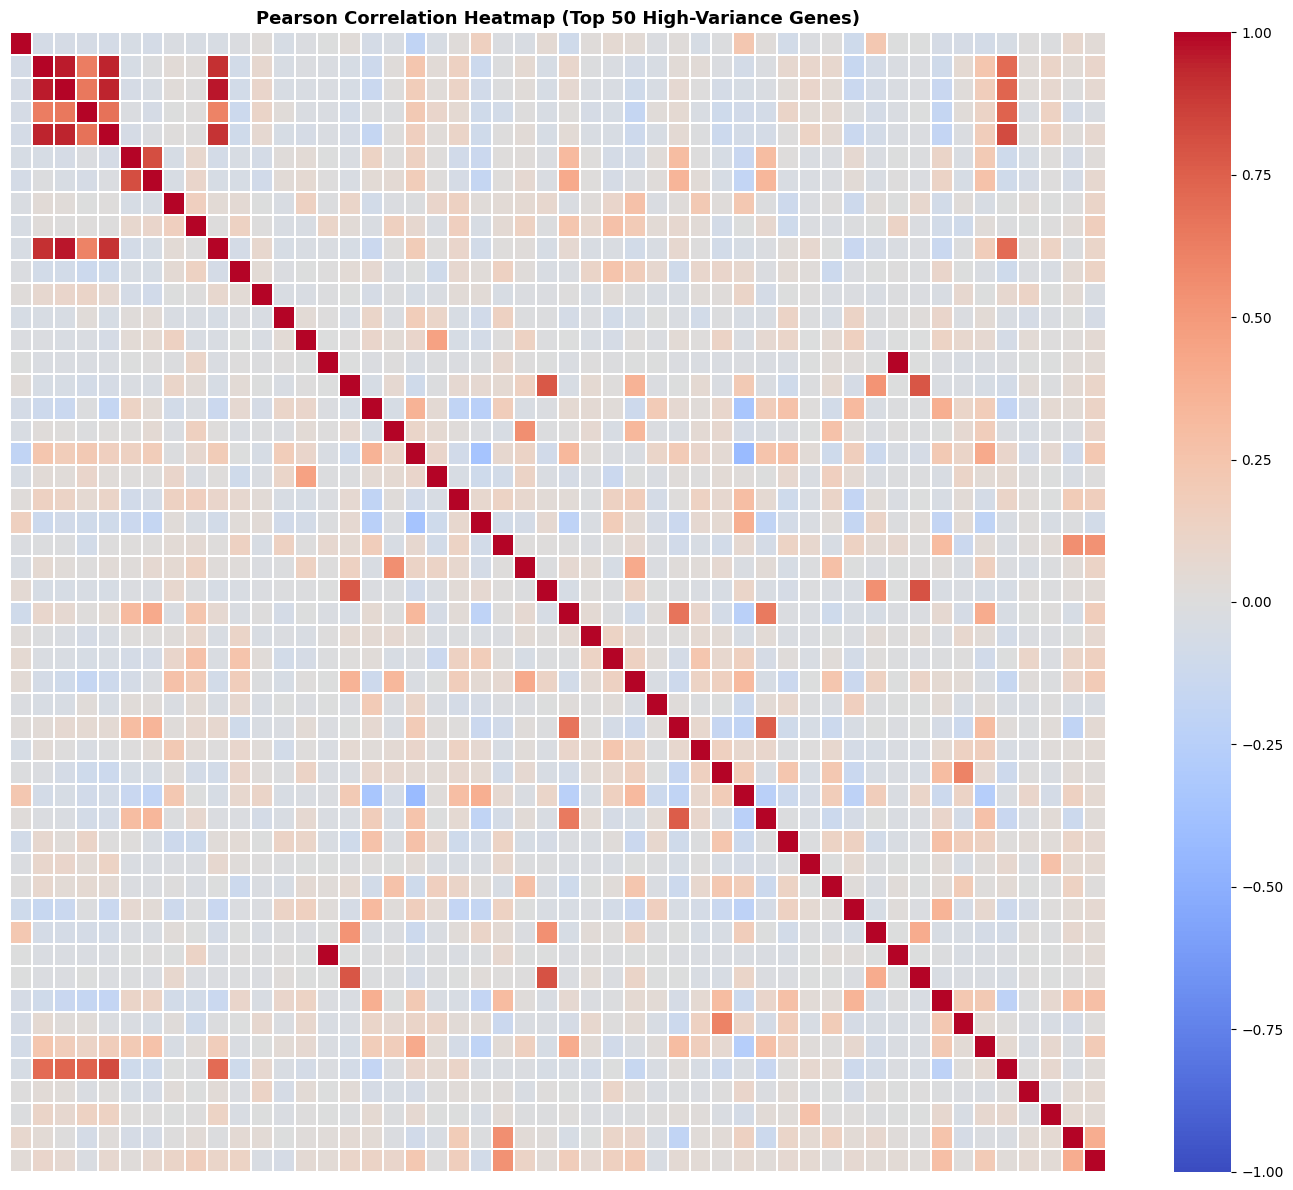

In [ ]:
# Use top 50 highest-variance genes for correlation heatmap
gene_var = X_raw.var()
top50_genes = gene_var.nlargest(50).index
corr_matrix = X_raw[top50_genes].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, linewidths=0.3,
            ax=ax, xticklabels=False, yticklabels=False, vmin=-1, vmax=1)
ax.set_title('Pearson Correlation Heatmap (Top 50 High-Variance Genes)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

2.6 Per-Class Expression Boxplot (Top 10 Variance Genes)

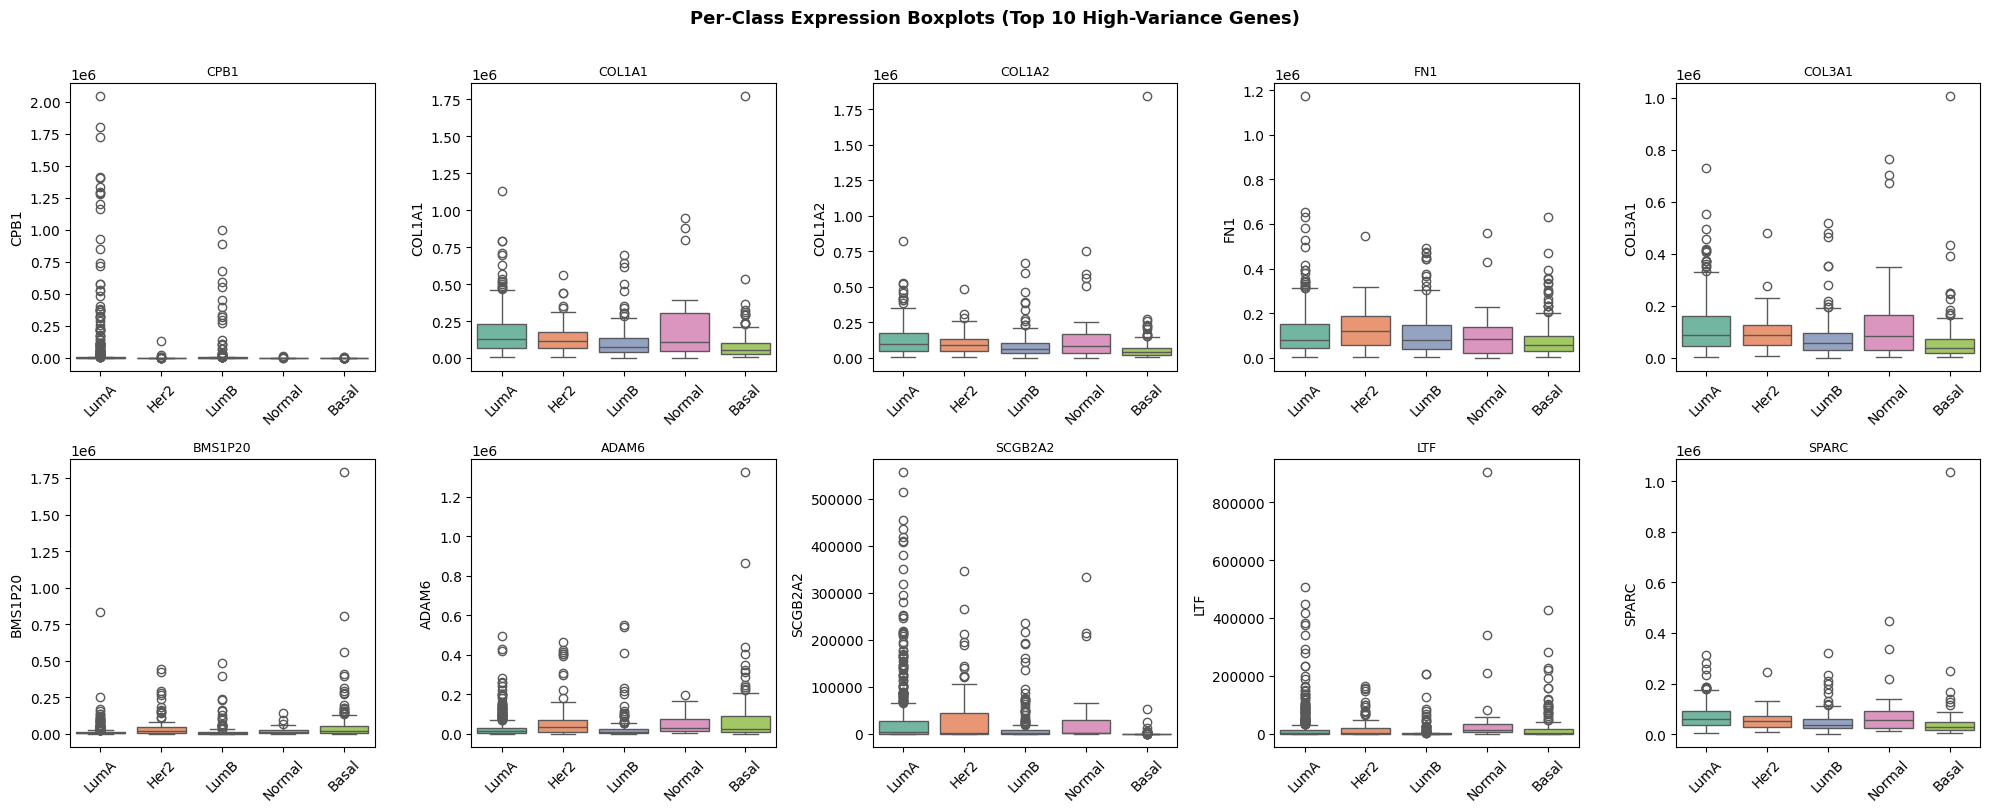

In [ ]:
top10_genes = gene_var.nlargest(10).index.tolist()
df_eda_plot = X_raw[top10_genes].copy()
df_eda_plot['SUBTYPE'] = y_raw.values

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
palette = sns.color_palette('Set2', df_eda_plot['SUBTYPE'].nunique())

for i, gene in enumerate(top10_genes):
    sns.boxplot(data=df_eda_plot, x='SUBTYPE', y=gene, ax=axes[i], palette=palette)
    axes[i].set_title(f'{gene}', fontsize=9)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

fig.suptitle('Per-Class Expression Boxplots (Top 10 High-Variance Genes)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

3. Data Preprocessing

3.1 Data Cleaning

In [ ]:
# Step 1: Remove duplicate samples
n_before = len(X_raw)
dup_mask = df_merged.duplicated(subset=['SAMPLE_ID'])
X_clean = X_raw[~dup_mask.values].copy()
y_clean = y_raw[~dup_mask.values].copy().reset_index(drop=True)
X_clean = X_clean.reset_index(drop=True)
print(f'Removed {dup_mask.sum()} duplicate samples. Shape: {X_clean.shape}')

# Step 2: Remove genes with >20% missing values
threshold = 0.20
missing_ratio = X_clean.isnull().mean()
genes_to_drop = missing_ratio[missing_ratio > threshold].index
X_clean = X_clean.drop(columns=genes_to_drop)
print(f'Dropped {len(genes_to_drop)} genes with >20% missing values. Shape: {X_clean.shape}')

# Step 3: Remove genes with zero variance
zero_var_mask = X_clean.var() == 0
X_clean = X_clean.loc[:, ~zero_var_mask]
print(f'Removed {zero_var_mask.sum()} zero-variance genes. Shape: {X_clean.shape}')

Removed 0 duplicate samples. Shape: (981, 20531)
Dropped 0 genes with >20% missing values. Shape: (981, 20531)
Removed 301 zero-variance genes. Shape: (981, 20230)


3.2 Missing Value Imputation

In [ ]:
# Median imputation for remaining missing values 
n_missing = X_clean.isnull().sum().sum()
print(f'Remaining missing values before imputation: {n_missing}')

if n_missing > 0:
    imputer = SimpleImputer(strategy='median')
    X_imputed = pd.DataFrame(imputer.fit_transform(X_clean),
                              columns=X_clean.columns)
    print('Median imputation applied.')
else:
    X_imputed = X_clean.copy()
    print('No imputation required.')

print(f'Shape after imputation: {X_imputed.shape}')

Remaining missing values before imputation: 0
No imputation required.
Shape after imputation: (981, 20230)


3.3 Log2 Transformation

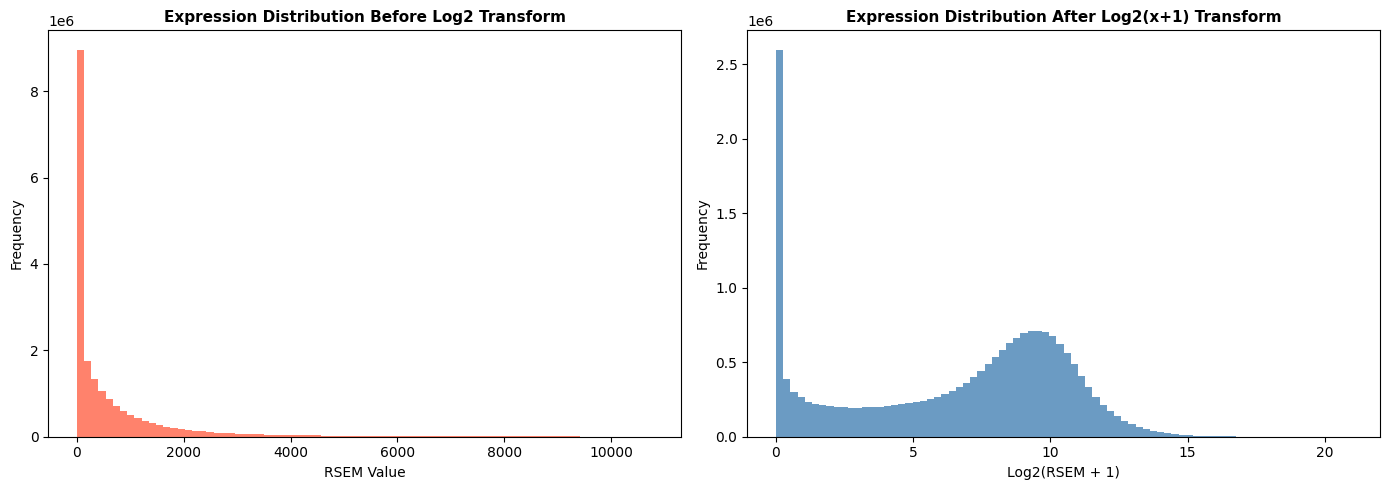

In [ ]:
# Log2(x+1) transformation
X_log = np.log2(X_imputed + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
sample_vals_before = X_imputed.values.flatten()
sample_vals_before = sample_vals_before[sample_vals_before < np.percentile(sample_vals_before, 99)]
axes[0].hist(sample_vals_before, bins=80, color='tomato', edgecolor='none', alpha=0.8)
axes[0].set_title('Expression Distribution Before Log2 Transform', fontsize=11, fontweight='bold')
axes[0].set_xlabel('RSEM Value')
axes[0].set_ylabel('Frequency')

# After
sample_vals_after = X_log.values.flatten()
axes[1].hist(sample_vals_after, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].set_title('Expression Distribution After Log2(x+1) Transform', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Log2(RSEM + 1)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

3.4 Z-Score Standardization

In [ ]:
# Z-score standardization
X_log.columns = X_log.columns.astype(str)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_log), columns=X_log.columns)

print(f'After Z-score standardization:')
print(f'  Mean (sample): {X_scaled.values.mean():.6f}')
print(f'  Std  (sample): {X_scaled.values.std():.6f}')
print(f'  Shape: {X_scaled.shape}')

After Z-score standardization:
  Mean (sample): 0.000000
  Std  (sample): 1.000000
  Shape: (981, 20230)


3.5 Label Encoding

In [ ]:
# Encode PAM50 subtypes to integer labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_clean)
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print('Label encoding mapping:', label_mapping)
print('Encoded label distribution:', Counter(y_encoded))

Label encoding mapping: {'Basal': 0, 'Her2': 1, 'LumA': 2, 'LumB': 3, 'Normal': 4}
Encoded label distribution: Counter({2: 499, 3: 197, 0: 171, 1: 78, 4: 36})


4. Feature Engineering

4.1 Variance Filtering

Data-driven cutoff: 16184 genes explain 80% of total variance
Features BEFORE variance filtering: 20230
Features AFTER variance filtering:  16262


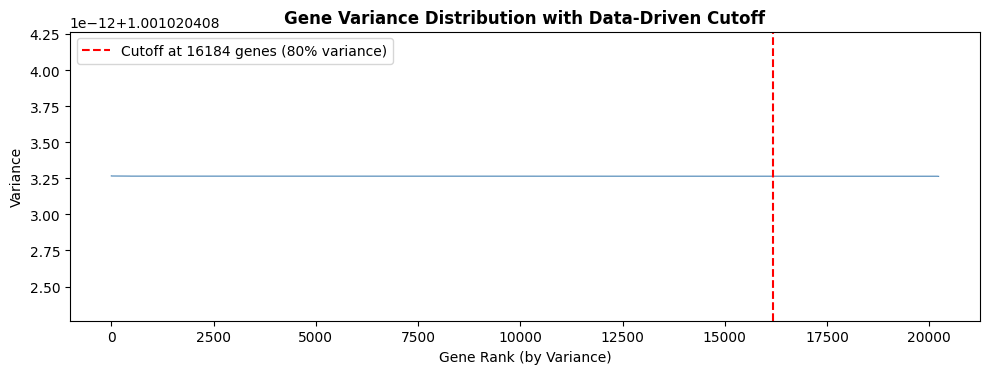

In [ ]:
# Keep top N genes by variance as a preliminary filter
gene_variances = X_scaled.var().sort_values(ascending=False)
cumulative_var = gene_variances.cumsum() / gene_variances.sum()
n_var_genes = int((cumulative_var <= 0.80).sum())
print(f'Data-driven cutoff: {n_var_genes} genes explain 80% of total variance')

top_var_genes = gene_variances.head(n_var_genes).index
X_var_filtered = X_scaled[top_var_genes]

print(f'Features BEFORE variance filtering: {X_scaled.shape[1]}')
print(f'Features AFTER variance filtering:  {X_var_filtered.shape[1]}')

# Plot variance distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(gene_variances)), gene_variances.values, color='steelblue', linewidth=0.8)
ax.axvline(x=n_var_genes, color='red', linestyle='--', label=f'Cutoff at {n_var_genes} genes (80% variance)')
ax.set_title('Gene Variance Distribution with Data-Driven Cutoff', fontsize=12, fontweight='bold')
ax.set_xlabel('Gene Rank (by Variance)')
ax.set_ylabel('Variance')
ax.legend()
plt.tight_layout()
plt.show()

4.2 ANOVA F-test Feature Selection (Filter Method)

Features after ANOVA F-test selection: 2000


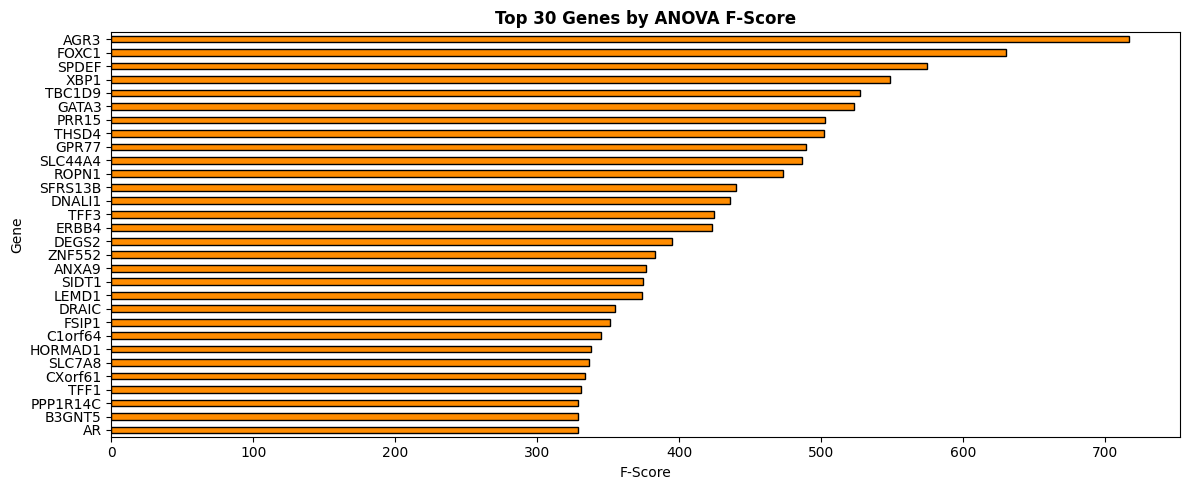

In [ ]:
# ANOVA F-test: select top 2,000 genes most significantly different across subtypes
n_anova = 2000
anova_selector = SelectKBest(score_func=f_classif, k=n_anova)
X_anova = anova_selector.fit_transform(X_var_filtered, y_encoded)
selected_genes_anova = X_var_filtered.columns[anova_selector.get_support()]

print(f'Features after ANOVA F-test selection: {X_anova.shape[1]}')

# Plot top 30 F-scores
f_scores = pd.Series(anova_selector.scores_, index=X_var_filtered.columns)
top30_f = f_scores.nlargest(30)

fig, ax = plt.subplots(figsize=(12, 5))
top30_f.sort_values().plot(kind='barh', ax=ax, color='darkorange', edgecolor='black')
ax.set_title('Top 30 Genes by ANOVA F-Score', fontsize=12, fontweight='bold')
ax.set_xlabel('F-Score')
ax.set_ylabel('Gene')
plt.tight_layout()
plt.show()

4.3 Mutual Information Feature Selection

In [ ]:
# Mutual Information: capture non-linear gene-subtype dependencies
n_mi = 2000
mi_selector = SelectKBest(score_func=mutual_info_classif, k=n_mi)
X_mi = mi_selector.fit_transform(X_var_filtered, y_encoded)
selected_genes_mi = X_var_filtered.columns[mi_selector.get_support()]

# Union of ANOVA and MI selected genes for robust feature set
selected_genes_union = list(set(selected_genes_anova) | set(selected_genes_mi))
X_fs = X_var_filtered[selected_genes_union]
print(f'Features after union of ANOVA + MI selection: {X_fs.shape[1]}')

Features after union of ANOVA + MI selection: 2268


4.4 PCA Feature Extraction

Components needed to explain 95% variance: 417


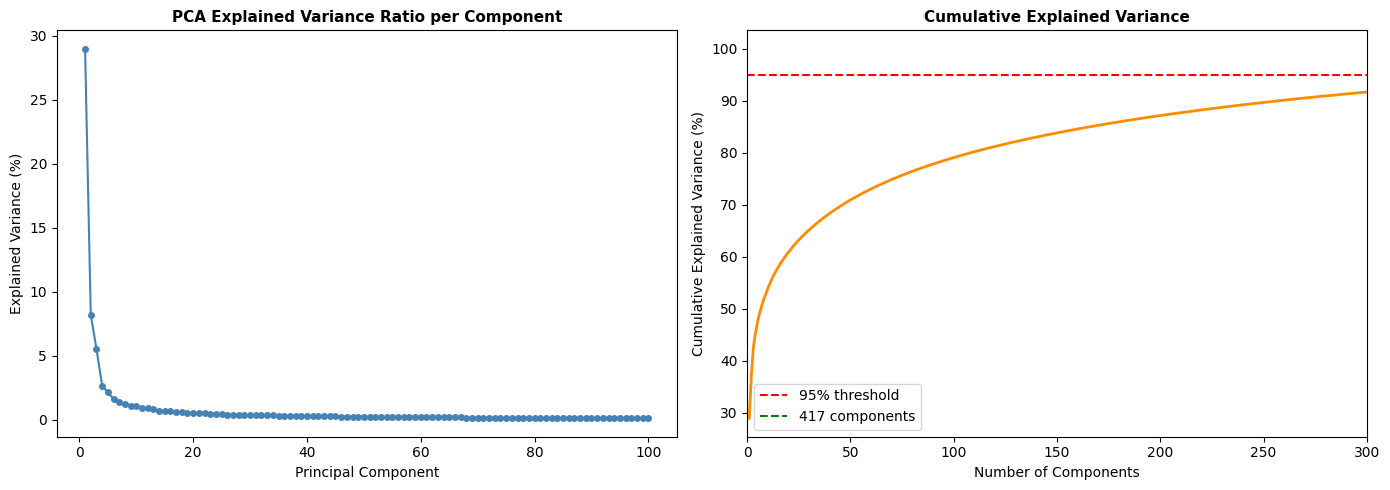

In [ ]:
# PCA: reduce to components explaining ≥95% cumulative variance
pca_full = PCA(random_state=42)
pca_full.fit(X_fs)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumvar >= 0.95) + 1
print(f'Components needed to explain 95% variance: {n_components_95}')

# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_show = min(100, len(pca_full.explained_variance_ratio_))
axes[0].plot(range(1, n_show + 1),
             pca_full.explained_variance_ratio_[:n_show] * 100, 'o-', color='steelblue', markersize=4)
axes[0].set_title('PCA Explained Variance Ratio per Component', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')

axes[1].plot(range(1, len(cumvar)+1), cumvar * 100, color='darkorange', linewidth=2)
axes[1].axhline(y=95, color='red', linestyle='--', label='95% threshold')
axes[1].axvline(x=n_components_95, color='green', linestyle='--', label=f'{n_components_95} components')
axes[1].set_title('Cumulative Explained Variance', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].legend()
axes[1].set_xlim([0, min(300, len(cumvar))])

plt.tight_layout()
plt.show()

In [ ]:
# Apply PCA with selected number of components
pca = PCA(n_components=n_components_95, random_state=42)
X_pca = pca.fit_transform(X_fs)
print(f'\nFeature dimensions BEFORE PCA: {X_fs.shape[1]}')
print(f'Feature dimensions AFTER PCA:  {X_pca.shape[1]}')


Feature dimensions BEFORE PCA: 2268
Feature dimensions AFTER PCA:  417


4.5 PCA 2D Visualization

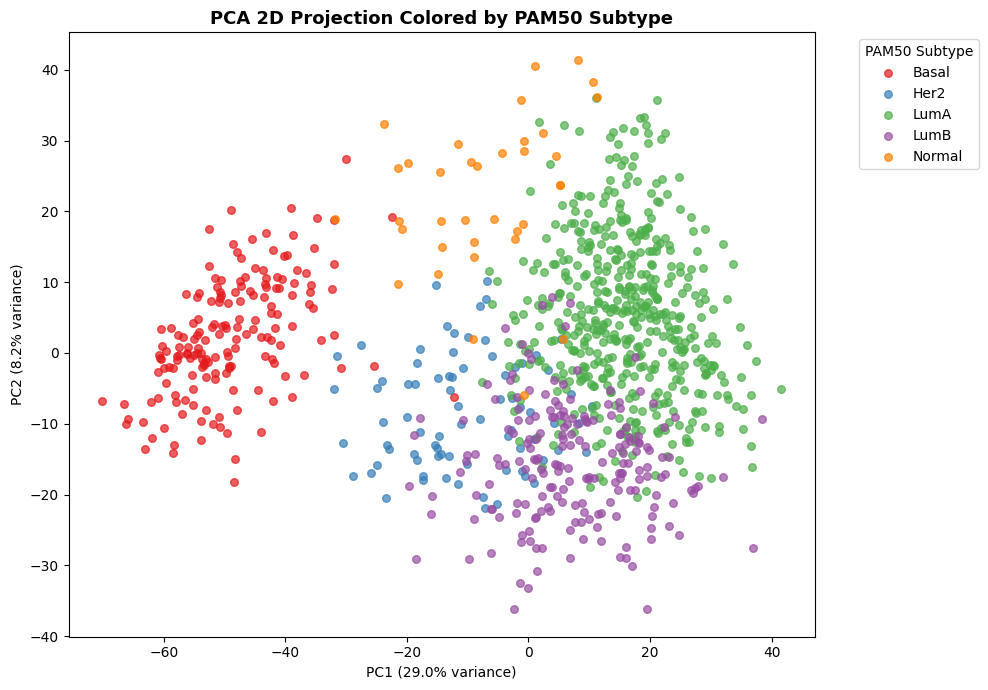

In [ ]:
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_fs)

fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette('Set1', len(np.unique(y_clean)))
for i, cls in enumerate(np.unique(y_clean)):
    mask = y_clean.values == cls
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], label=cls, alpha=0.7, s=30, color=palette[i])

ax.set_title('PCA 2D Projection Colored by PAM50 Subtype', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(title='PAM50 Subtype', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

4.6 Feature Engineering Summary

In [ ]:
print('=' * 60)
print('FEATURE ENGINEERING SUMMARY')
print('=' * 60)
print(f'Original features (genes):                  {X_scaled.shape[1]:>8}')
print(f'After variance filtering (top 5000):        {X_var_filtered.shape[1]:>8}')
print(f'After ANOVA + MI union selection:           {X_fs.shape[1]:>8}')
print(f'After PCA (95% variance):                   {X_pca.shape[1]:>8}')
print('=' * 60)

FEATURE ENGINEERING SUMMARY
Original features (genes):                     20230
After variance filtering (top 5000):           16262
After ANOVA + MI union selection:               2268
After PCA (95% variance):                        417


5. Class Imbalance Handling

In [ ]:
# Visualize class imbalance before treatment
counter_before = Counter(y_encoded)
print('Class distribution BEFORE imbalance handling:')
for label, count in sorted(counter_before.items()):
    print(f'  {le.inverse_transform([label])[0]:20s}: {count}')

imbalance_ratio = max(counter_before.values()) / min(counter_before.values())
print(f'\nImbalance ratio (max/min): {imbalance_ratio:.2f}')

Class distribution BEFORE imbalance handling:
  Basal               : 171
  Her2                : 78
  LumA                : 499
  LumB                : 197
  Normal              : 36

Imbalance ratio (max/min): 13.86


In [ ]:
# Apply SMOTE on training split only
from sklearn.model_selection import train_test_split

# Use PCA features for splitting
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_pca, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded)

# Validation split from training
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_raw, y_train, test_size=0.15, random_state=42, stratify=y_train)

print(f'Train size:      {X_train_raw.shape}')
print(f'Validation size: {X_val_raw.shape}')
print(f'Test size:       {X_test_raw.shape}')

Train size:      (666, 417)
Validation size: (118, 417)
Test size:       (197, 417)


In [ ]:
# SMOTE k_neighbors Tuning
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

k_values = [3, 5, 7]
smote_results = []

for k in k_values:
    smote_test = SMOTE(k_neighbors=k, random_state=42)
    X_tr_s, y_tr_s = smote_test.fit_resample(X_train_raw, y_train)
    
    # Quick LR probe to evaluate quality of resampled data
    probe = LogisticRegression(max_iter=500, random_state=42)
    probe.fit(X_tr_s, y_tr_s)
    f1 = f1_score(y_val, probe.predict(X_val_raw), average='macro', zero_division=0)
    smote_results.append((k, f1))
    print(f'k_neighbors={k} → Validation F1-macro: {f1:.4f}')

best_k = max(smote_results, key=lambda x: x[1])[0]
print(f'\nBest k_neighbors: {best_k}')

# Apply SMOTE with best k
smote = SMOTE(k_neighbors=best_k, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_raw, y_train)

k_neighbors=3 → Validation F1-macro: 0.8597
k_neighbors=5 → Validation F1-macro: 0.8597
k_neighbors=7 → Validation F1-macro: 0.8597

Best k_neighbors: 3


In [35]:
counter_after = Counter(y_train_smote)
print('Class distribution AFTER SMOTE (training set only):')
for label, count in sorted(counter_after.items()):
    print(f'  {le.inverse_transform([label])[0]:20s}: {count}')

Class distribution AFTER SMOTE (training set only):
  Basal               : 339
  Her2                : 339
  LumA                : 339
  LumB                : 339
  Normal              : 339


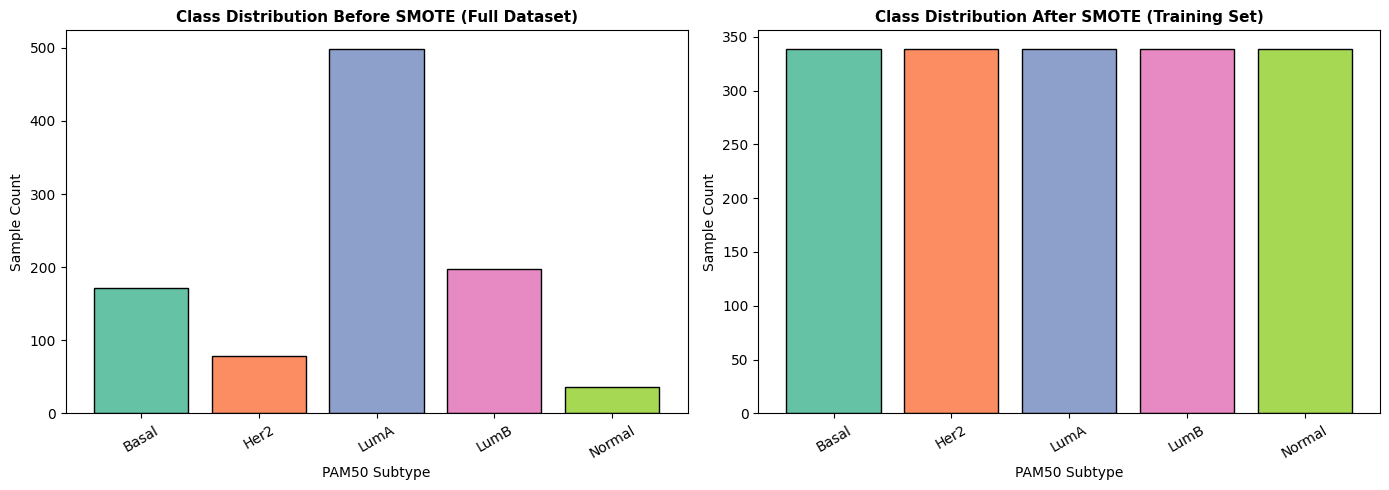

In [ ]:
# Visualization: before vs after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

classes_str = [le.inverse_transform([k])[0] for k in sorted(counter_before.keys())]
counts_before = [counter_before[k] for k in sorted(counter_before.keys())]
counts_after  = [counter_after[k]  for k in sorted(counter_after.keys())]

colors = sns.color_palette('Set2', len(classes_str))
axes[0].bar(classes_str, counts_before, color=colors, edgecolor='black')
axes[0].set_title('Class Distribution Before SMOTE (Full Dataset)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('PAM50 Subtype')
axes[0].set_ylabel('Sample Count')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(classes_str, counts_after, color=colors, edgecolor='black')
axes[1].set_title('Class Distribution After SMOTE (Training Set)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('PAM50 Subtype')
axes[1].set_ylabel('Sample Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

6. Save Preprocessed Datasets

In [ ]:
import pickle

# Save all preprocessed objects
output = {
    # Feature matrices
    'X_fs': X_fs,                        # Gene-level features (selected genes, pre-PCA)
    'X_pca': X_pca,                      # PCA-reduced features
    'y_encoded': y_encoded,              # Encoded labels
    'y_raw': y_clean,                    # String labels
    # Splits
    'X_train': X_train_smote,            # SMOTE-balanced training features
    'y_train': y_train_smote,            # SMOTE-balanced training labels
    'X_val': X_val_raw,
    'y_val': y_val,
    'X_test': X_test_raw,
    'y_test': y_test,
    # Transformers
    'scaler': scaler,
    'pca': pca,
    'label_encoder': le,
    'selected_genes': selected_genes_union,
    'n_components': n_components_95,
}

with open('preprocessed_data.pkl', 'wb') as f:
    pickle.dump(output, f)

print('Preprocessed data saved to preprocessed_data.pkl')
print('\nSummary:')
print(f'  X_train (SMOTE): {X_train_smote.shape}')
print(f'  X_val:           {X_val_raw.shape}')
print(f'  X_test:          {X_test_raw.shape}')
print(f'  Classes:         {list(le.classes_)}')

Preprocessed data saved to preprocessed_data.pkl

Summary:
  X_train (SMOTE): (1695, 417)
  X_val:           (118, 417)
  X_test:          (197, 417)
  Classes:         ['Basal', 'Her2', 'LumA', 'LumB', 'Normal']
